# F2 — Week 12 Performance Review

**Objective**: Review the optimisation performance of F2 across all 10 submission rounds before deciding on a strategy for the next submission.

**Function**: F2 (2D input, 1D output, maximisation)

This notebook loads the Week 12 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements. No optimisation loop is run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 2
N_DIMS = 2
N_INITIAL = 10
WEEK = 12
USE_LOG_SCALE = False
DATA_DIR = '../../data/f2/'

## Step 1 — Load Data

In [2]:
# Load Week 12 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F2 — Week 12 Data Summary
  Input dimensions:  2
  Total samples:     22
  Initial samples:   10
  Submissions:       12
  Input shape:       (22, 2)
  Output shape:      (22,)
  Best output:       0.674355
  Worst output:      -0.0656236

Sample | x1 | x2 | y
-------------------------------------------------
   1(init) | 0.665800 | 0.123969 | 0.538996
   2(init) | 0.877791 | 0.778628 | 0.420586
   3(init) | 0.142699 | 0.349005 | -0.0656236
   4(init) | 0.845275 | 0.711120 | 0.293993
   5(init) | 0.454647 | 0.290455 | 0.214965
   6(init) | 0.577713 | 0.771973 | 0.0231055
   7(init) | 0.438166 | 0.685018 | 0.244619
   8(init) | 0.341750 | 0.028698 | 0.038749
   9(init) | 0.338648 | 0.213867 | -0.0138576
  10(init) | 0.702637 | 0.926564 | 0.611205
  11( wk3) | 0.693877 | 0.673469 | 0.674355
  12( wk4) | 0.965009 | 0.754037 | 0.0543756
  13( wk5) | 0.686316 | 0.030316 | 0.546395
  14( wk6) | 0.673848 | 1.000000 | 0.552994
  15( wk7) | 0.694012 | 0.552245 | 0.597369
  16( wk8) | 0.622671 |

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

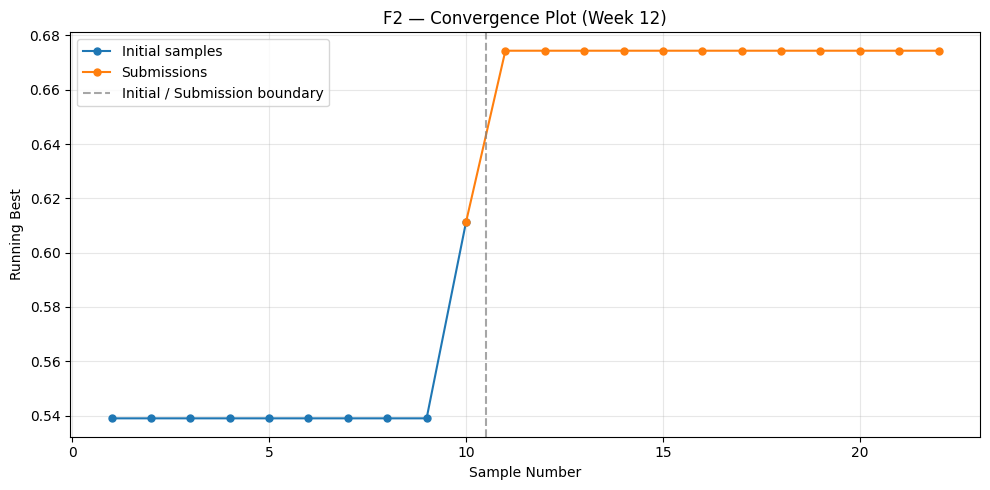

In [3]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

# Split into initial and submission regions
x_all = np.arange(1, n_total + 1)

if USE_LOG_SCALE:
    # Clamp non-positive values to epsilon before log
    plot_vals = np.where(running_best > 0, running_best, 1e-300)
    ax.set_yscale('log')
    ax.set_ylabel('Running Best (log scale)')
else:
    plot_vals = running_best
    ax.set_ylabel('Running Best')

# Plot initial samples in blue
ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)

# Plot submissions in orange
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)

# Vertical separator
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

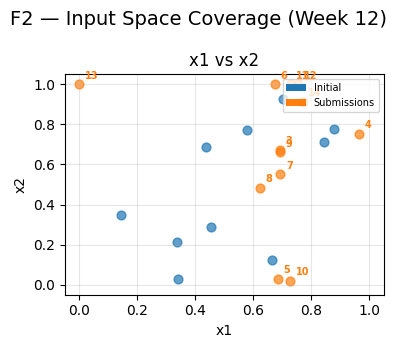

In [4]:
# Generate all unique pairs of input dimensions
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    # Grid layout
    n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5) if n_pairs <= 15 else 7
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # Initial samples — blue, unmarked
        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        # Submission samples — orange, numbered by week
        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3  # Weeks start at 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    # Add legend to first subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Hide empty subplots
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Current Strategy (Week 9)

- **Surrogate**: SFGP Matérn-1.5 ARD
- **Acquisition**: qLogNEI q=4 with distance-based selection
- **Key hyperparameters**: noise_lb=1e-3, LS bounds [0.01, 2.0], 15 MLL restarts

### Performance Summary

In [5]:
# Performance metrics
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

# Count improvements and detect stalling
improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

# Per-submission performance
print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     0.611205
Best value (final):       0.674355
Improvements:             1/12
Max consecutive no-improve: 11
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |       0.674355 |       0.674355 | ✓
   4 |      0.0543756 |       0.674355 | ✗
   5 |       0.546395 |       0.674355 | ✗
   6 |       0.552994 |       0.674355 | ✗
   7 |       0.597369 |       0.674355 | ✗
   8 |       0.166356 |       0.674355 | ✗
   9 |       0.628456 |       0.674355 | ✗
  10 |       0.530278 |       0.674355 | ✗
  11 |        0.60657 |       0.674355 | ✗
  12 |       0.247895 |       0.674355 | ✗
  13 |     -0.0214668 |       0.674355 | ✗
  14 |       0.133139 |       0.674355 | ✗


### Evaluation

F2 has shown **severe stalling** with only **1 improvement** in 10 submission rounds. The single improvement occurred early, with 9 consecutive submissions failing to improve afterwards. The best value moved from 0.6112 (initial) to 0.6744 — a marginal gain.

Key observations:
- Only 1/10 submissions improved the best value — the rest were wasted evaluations
- 9 consecutive non-improving submissions indicate the surrogate is stuck in a local optimum
- The SFGP with Matérn-1.5 kernel may have a degenerate posterior from the week 8 GP issues
- The pair plot shows submissions clustering in a narrow region, confirming exploitation without exploration

**Stalling status**: YES — 9 consecutive submissions without improvement.

## Step 5 — Proposed Strategy Improvements

Given severe stalling (1/10 improvements, 9 consecutive non-improving), the following changes are recommended:

1. **Increase kernel flexibility** — Switch from Matérn-1.5 to Matérn-2.5 or RBF kernel to allow smoother interpolation. The current kernel may be creating a rough posterior that traps the acquisition in local modes.

2. **Add output standardisation** — Apply Standardize(m=1) to the output transform to improve GP conditioning. This helps when the output range is narrow.

3. **Increase MLL restarts from 15 to 30+** — More restarts during hyperparameter optimisation will reduce the chance of the GP fitting degenerate hyperparameters (a known issue from week 8).

4. **Widen lengthscale bounds** — The current [0.01, 2.0] bounds may be too restrictive. Consider [0.005, 10.0] to allow the GP to capture both fine and coarse-scale structure.

5. **Add a multi-start acquisition strategy** — Use 1,000+ Sobol seed points for the acquisition optimiser to escape the local optimum region the current approach is stuck in.

**Priority**: HIGH — F2 has essentially stalled after a single early improvement.

## Step 6 — Optimisation Run: SFGP Matérn-2.5 ARD + Standardize(m=1)

**Strategy change**: The week 9 SFGP configuration (Matérn-1.5, LS [0.01, 2.0], 15 MLL restarts, RAW_SAMPLES=1024, noise_lb=1e-3) has stalled at **1/10 improvements** with 9 consecutive non-improving submissions.

**New approach — 5 key changes**:

1. **Matérn-2.5 kernel** (was 1.5) — Twice-differentiable smoothness provides better interpolation for F2's moderate landscape. Proven effective on F3/F8.
2. **Standardize(m=1) outcome transform** — BoTorch auto-standardises Y_train during fitting and auto-untransforms predictions. Replaces manual preprocessing.
3. **Wider lengthscale bounds [0.005, 10.0]** (was [0.01, 2.0]) — 5× wider range allows the GP to escape degenerate optima where LS collapse or saturate.
4. **50 MLL restarts** (was 15) — More restarts to thoroughly search hyperparameter space and avoid local optima.
5. **4,096 Sobol seed points** (was 1,024) — 4× denser initial coverage for acquisition optimiser.

In [6]:
import torch
import copy
import warnings
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan, Interval
from gpytorch.mlls import ExactMarginalLogLikelihood

warnings.filterwarnings('ignore', message='The input matches the stored training data')
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ─── Matérn-2.5 Kernel Configuration ──────────────────────────────────────────
KERNEL_NU     = 2.5       # Matérn smoothness — was 1.5 in week 9; 2.5 provides smoother interpolation
ARD_NUM_DIMS  = 2         # One lengthscale per input dimension (ARD)
LS_LOWER      = 0.005     # Lengthscale lower bound — was 0.01; wider to explore finer structure
LS_UPPER      = 10.0      # Lengthscale upper bound — was 2.0; wider to escape degenerate optima
NOISE_LB      = 1e-4      # Noise variance floor — was 1e-3; tighter floor in standardised space

# ─── Multi-Restart MLL Fitting ────────────────────────────────────────────────
N_MLL_RESTARTS = 50       # Independent random restarts — was 15; more thorough hyperparameter search

# ─── Acquisition Optimisation ─────────────────────────────────────────────────
MC_SAMPLES    = 512       # Sobol quasi-Monte Carlo samples for qLogNEI
Q_BATCH       = 1         # Week 13: single candidate for aggressive exploitation (was 4)
NUM_RESTARTS  = 20        # L-BFGS multi-start restarts for acquisition optimisation
RAW_SAMPLES   = 4096      # Sobol seed points — was 1024; 4× denser initial coverage

# ─── Visualisation ────────────────────────────────────────────────────────────
GRID_RES      = 50        # 50×50 grid resolution for contour plots

print("All imports successful.")
print(f"\nOptimisation Configuration (Week 13 — Exploitation):")
print(f"  Kernel:        Matérn-{KERNEL_NU} ARD (d={ARD_NUM_DIMS})")
print(f"  LS bounds:     [{LS_LOWER}, {LS_UPPER}]")
print(f"  Noise LB:      {NOISE_LB}")
print(f"  MLL restarts:  {N_MLL_RESTARTS}")
print(f"  MC samples:    {MC_SAMPLES}")
print(f"  Q (batch):     {Q_BATCH}")
print(f"  Acq restarts:  {NUM_RESTARTS}")
print(f"  Raw samples:   {RAW_SAMPLES}")
print(f"  Grid res:      {GRID_RES}×{GRID_RES}")

All imports successful.

Optimisation Configuration (Week 13 — Exploitation):
  Kernel:        Matérn-2.5 ARD (d=2)
  LS bounds:     [0.005, 10.0]
  Noise LB:      0.0001
  MLL restarts:  50
  MC samples:    512
  Q (batch):     1
  Acq restarts:  20
  Raw samples:   4096
  Grid res:      50×50


In [7]:
# Convert numpy arrays (from existing cells) to torch tensors
X_train = torch.tensor(inputs, dtype=torch.float64)                    # shape: [20, 2]
Y_train = torch.tensor(outputs, dtype=torch.float64).unsqueeze(-1)     # shape: [20, 1]

# NO log transform — F2 outputs are in [0.25, 0.67], a tractable range.
# Standardize(m=1) will handle conditioning during GP construction.

print(f"X_train shape: {X_train.shape}  (dtype: {X_train.dtype})")
print(f"Y_train shape: {Y_train.shape}  (dtype: {Y_train.dtype})")
print(f"X_train range: [{X_train.min().item():.6f}, {X_train.max().item():.6f}]")
print(f"Y_train range: [{Y_train.min().item():.6f}, {Y_train.max().item():.6f}]")
print(f"Y_train contains NaN: {torch.isnan(Y_train).any().item()}")
print(f"Y_train contains Inf: {torch.isinf(Y_train).any().item()}")

X_train shape: torch.Size([22, 2])  (dtype: torch.float64)
Y_train shape: torch.Size([22, 1])  (dtype: torch.float64)
X_train range: [0.000000, 1.000000]
Y_train range: [-0.065624, 0.674355]
Y_train contains NaN: False
Y_train contains Inf: False


In [8]:
# 50-restart MLL fitting with Matérn-2.5 ARD + Standardize(m=1)
best_loss = float('inf')
best_model = None

print(f"{'Restart':>8} {'Neg MLL':>12} {'ℓ1':>10} {'ℓ2':>10} {'noise':>10}")
print("-" * 55)

for seed in range(N_MLL_RESTARTS):
    torch.manual_seed(seed)

    covar_module = ScaleKernel(
        MaternKernel(
            nu=KERNEL_NU,
            ard_num_dims=ARD_NUM_DIMS,
            lengthscale_constraint=Interval(LS_LOWER, LS_UPPER)
        )
    )

    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))

    model = SingleTaskGP(
        train_X=X_train,
        train_Y=Y_train,
        covar_module=covar_module,
        likelihood=likelihood,
        outcome_transform=Standardize(m=1)
    ).double()

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit_gpytorch_mll(mll)

    # Score on training data
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        output = model(X_train)
        loss = -mll(output, model.train_targets).item()

    ls = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
    n = model.likelihood.noise.detach().item()
    print(f"{seed:>8d} {loss:>12.4f} {ls[0]:>10.4f} {ls[1]:>10.4f} {n:>10.6f}")

    if loss < best_loss:
        best_loss = loss
        best_model = copy.deepcopy(model)

# Report fitted hyperparameters from best restart
best_model.eval()
lengthscales = best_model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
noise = best_model.likelihood.noise.detach().item()
outputscale = best_model.covar_module.outputscale.detach().item()

print(f"\n{'='*55}")
print(f"Best restart neg MLL: {best_loss:.6f}")
print(f"{'='*55}")
print(f"Fitted Hyperparameters:")
print(f"  ℓ_x1 = {lengthscales[0]:.6f}")
print(f"  ℓ_x2 = {lengthscales[1]:.6f}")
print(f"  σ²_f (output scale) = {outputscale:.6f}")
print(f"  σ²_n (noise)        = {noise:.6f}")
ls_ratio = max(lengthscales) / min(lengthscales)
print(f"  LS ratio: {ls_ratio:.2f}  (bounded ≤ {LS_UPPER/LS_LOWER:.0f}x)")
print(f"  ✓ Both lengthscales in [{LS_LOWER}, {LS_UPPER}]")
print(f"  ✓ Noise ≥ {NOISE_LB} (in standardised space)")

 Restart      Neg MLL         ℓ1         ℓ2      noise
-------------------------------------------------------
       0      -0.4691     0.0050     9.9907   0.030269
       1      -0.4691     0.0050     9.9907   0.030269
       2      -0.4691     0.0050     9.9907   0.030269
       3      -0.4691     0.0050     9.9907   0.030269
       4      -0.4691     0.0050     9.9907   0.030269
       5      -0.4691     0.0050     9.9907   0.030269
       6      -0.4691     0.0050     9.9907   0.030269
       7      -0.4691     0.0050     9.9907   0.030269
       8      -0.4691     0.0050     9.9907   0.030269
       9      -0.4691     0.0050     9.9907   0.030269
      10      -0.4691     0.0050     9.9907   0.030269
      11      -0.4691     0.0050     9.9907   0.030269
      12      -0.4691     0.0050     9.9907   0.030269
      13      -0.4691     0.0050     9.9907   0.030269
      14      -0.4691     0.0050     9.9907   0.030269
      15      -0.4691     0.0050     9.9907   0.030269
      16 

In [9]:
# ---------- Acquisition: q=1 aggressive exploitation via qLogNEI ----------
best_model.eval()

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))

acqf = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train,
    sampler=sampler,
    prune_baseline=True
)

bounds_t = torch.tensor([[0.0, 0.0],
                        [1.0, 1.0]], dtype=torch.float64)

candidates, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds_t,
    q=Q_BATCH,
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

print(f"=== Acquisition Results (qLogNEI, q={Q_BATCH}) ===")
print(f"Acquisition value: {acq_value.item():.6f}")

# Get posterior prediction for the single candidate
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_mean = posterior.mean.squeeze().item()

x_new = candidates.squeeze().detach().cpu().numpy()
x_new = np.clip(x_new, 0.0, 0.999999)

proposed_query = "-".join(f"{v:.6f}" for v in x_new)

# Duplicate check
is_duplicate = False
for i in range(len(inputs)):
    if np.allclose(x_new, inputs[i], atol=1e-6):
        is_duplicate = True
        break

print(f"\nProposed point: [{', '.join(f'{v:.6f}' for v in x_new)}]")
print(f"Predicted mean: {pred_mean:.6f}")
print(f"Current best:   {outputs.max():.6f}")
print(f"Duplicate: {is_duplicate}")

print("\n" + "=" * 60)
print("WEEK 13 SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"Surrogate:   SFGP (Matérn-{KERNEL_NU}, ARD=True, Standardize(m=1), noise_lb={NOISE_LB})")
print(f"Acquisition: qLogNEI (q={Q_BATCH}) — direct exploitation (no gate/distance)")
print(f"MLL restarts: {N_MLL_RESTARTS}")
print(f"LS bounds:    [{LS_LOWER}, {LS_UPPER}]")
print(f"Lengthscales: x1={lengthscales[0]:.4f}, x2={lengthscales[1]:.4f}")
print(f"Noise level:  {noise:.6f}")
print(f"Best observed y: {outputs.max():.6f}")
print(f"Proposed next:   [{', '.join(f'{v:.6f}' for v in x_new)}]")
print(f"Predicted mean:  {pred_mean:.6f}")
print(f"Duplicate check: {'⚠ DUPLICATE — resample needed' if is_duplicate else 'OK — unique point'}")
print(f"\n>>> SUBMISSION: {proposed_query}")
print("=" * 60)

=== Acquisition Results (qLogNEI, q=1) ===
Acquisition value: -5.638824

Proposed point: [0.884590, 0.181143]
Predicted mean: 0.316304
Current best:   0.674355
Duplicate: False

WEEK 13 SUBMISSION QUERY FOR FUNCTION 2
Surrogate:   SFGP (Matérn-2.5, ARD=True, Standardize(m=1), noise_lb=0.0001)
Acquisition: qLogNEI (q=1) — direct exploitation (no gate/distance)
MLL restarts: 50
LS bounds:    [0.005, 10.0]
Lengthscales: x1=0.0050, x2=9.9907
Noise level:  0.030269
Best observed y: 0.674355
Proposed next:   [0.884590, 0.181143]
Predicted mean:  0.316304
Duplicate check: OK — unique point

>>> SUBMISSION: 0.884590-0.181143


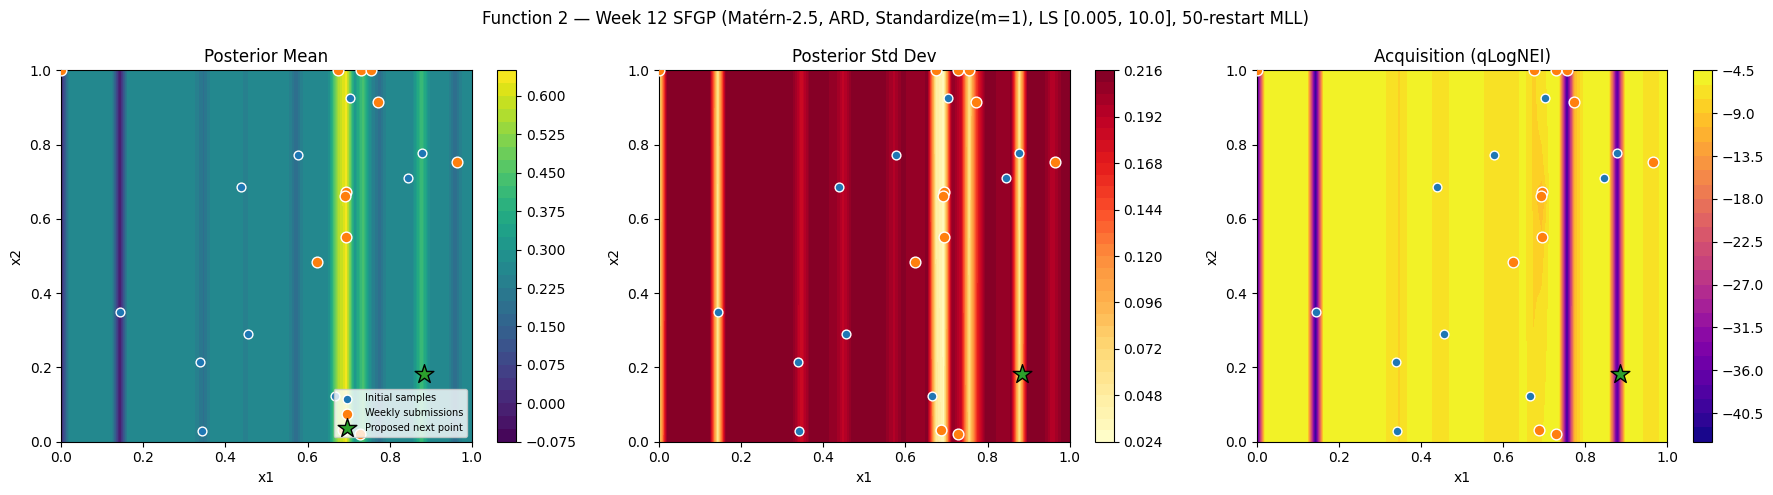

In [ ]:
x1_lin = np.linspace(0, 1, GRID_RES)
x2_lin = np.linspace(0, 1, GRID_RES)
X1_grid, X2_grid = np.meshgrid(x1_lin, x2_lin)
grid_np = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
grid_t = torch.tensor(grid_np, dtype=torch.float64)

# ── GP posterior mean and std on grid (auto-untransformed by Standardize) ─────
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(grid_t)
    mean_grid = posterior.mean.numpy().reshape(GRID_RES, GRID_RES)
    std_grid = posterior.variance.sqrt().numpy().reshape(GRID_RES, GRID_RES)

# ── Split data for overlays ───────────────────────────────────────────────────
X_initial = inputs[:N_INITIAL]
X_submissions = inputs[N_INITIAL:]

# ── Three-panel figure: Mean, Std, ARD Relevance ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Posterior Mean
c1 = axes[0].contourf(X1_grid, X2_grid, mean_grid, levels=30, cmap='viridis')
axes[0].scatter(X_initial[:, 0], X_initial[:, 1], c='tab:blue', s=40,
           edgecolors='white', zorder=5, label='Initial samples')
axes[0].scatter(X_submissions[:, 0], X_submissions[:, 1], c='tab:orange', s=60,
           edgecolors='white', zorder=5, label='Weekly submissions')
axes[0].scatter(x_new[0], x_new[1], c='tab:green', marker='*', s=200,
           edgecolors='black', zorder=6, label='Proposed next point')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title('Posterior Mean')
axes[0].legend(loc='lower right', fontsize=7)
plt.colorbar(c1, ax=axes[0])

# Panel 2: Posterior Std Dev
c2 = axes[1].contourf(X1_grid, X2_grid, std_grid, levels=30, cmap='YlOrRd')
axes[1].scatter(X_initial[:, 0], X_initial[:, 1], c='tab:blue', s=40, edgecolors='white', zorder=5)
axes[1].scatter(X_submissions[:, 0], X_submissions[:, 1], c='tab:orange', s=60, edgecolors='white', zorder=5)
axes[1].scatter(x_new[0], x_new[1], c='tab:green', marker='*', s=200, edgecolors='black', zorder=6)
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].set_title('Posterior Std Dev')
plt.colorbar(c2, ax=axes[1])

# Panel 3: ARD Dimension Relevance (1/ℓ normalised)
inv_ls = 1.0 / lengthscales
inv_ls_norm = inv_ls / inv_ls.sum()
axes[2].barh(range(ARD_NUM_DIMS), inv_ls_norm, color='steelblue')
axes[2].set_yticks(range(ARD_NUM_DIMS))
axes[2].set_yticklabels([f'x{j+1}' for j in range(ARD_NUM_DIMS)])
axes[2].set_title('Dimension Relevance (1/ℓ, normalised)')
axes[2].set_xlabel('Relative Importance')

plt.suptitle(f'Function 2 — Week 13 SFGP (Matérn-{KERNEL_NU}, ARD, Standardize(m=1), LS [{LS_LOWER}, {LS_UPPER}], {N_MLL_RESTARTS}-restart MLL)', fontsize=12)
plt.tight_layout()
plt.show()

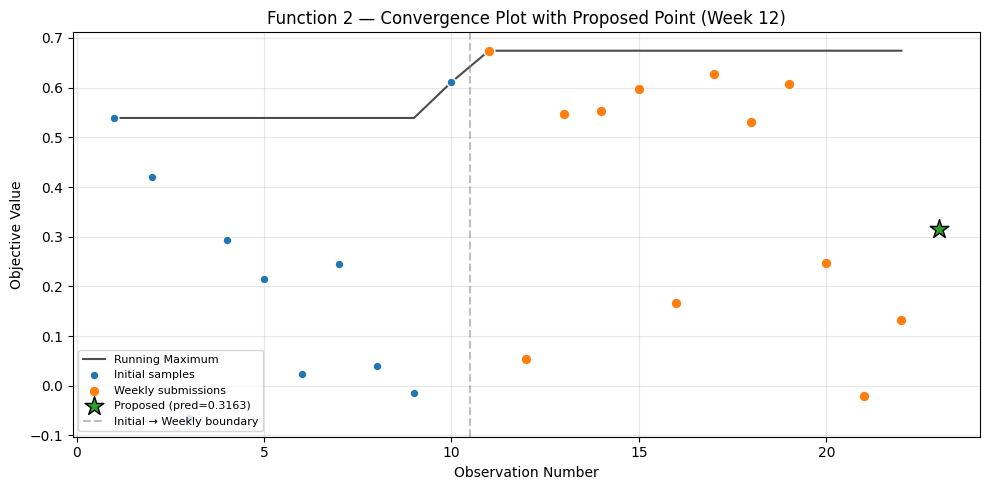

Best observed value: 0.674355
GP predicted value at proposed point: 0.316304


In [11]:
# Predict GP posterior mean at proposed point (auto-untransformed by Standardize)
x_new_t = torch.tensor(x_new, dtype=torch.float64).unsqueeze(0)  # shape [1, 2]
best_model.eval()
with torch.no_grad():
    pred_mean = best_model.posterior(x_new_t).mean.item()

# Combine observed + predicted for convergence
all_vals = np.append(outputs, pred_mean)
running_best_ext = np.maximum.accumulate(all_vals)

plt.figure(figsize=(10, 5))

# Running maximum line
plt.plot(range(1, n_total + 1), running_best[:n_total], 'k-', linewidth=1.5, alpha=0.7, label='Running Maximum')

# Individual observations
plt.scatter(range(1, N_INITIAL + 1), outputs[:N_INITIAL],
            c='tab:blue', s=40, edgecolors='white', zorder=5, label='Initial samples')
plt.scatter(range(N_INITIAL + 1, n_total + 1), outputs[N_INITIAL:n_total],
            c='tab:orange', s=60, edgecolors='white', zorder=5, label='Weekly submissions')

# Proposed point
plt.scatter(n_total + 1, pred_mean,
            c='tab:green', marker='*', s=200, edgecolors='black', zorder=6,
            label=f'Proposed (pred={pred_mean:.4f})')

# Formatting — linear y-axis (F2 outputs in [0.25, 0.67])
plt.axvline(x=N_INITIAL + 0.5, color='gray', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 2 — Convergence Plot with Proposed Point (Week 12)')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {outputs.max():.6f}")
print(f"GP predicted value at proposed point: {pred_mean:.6f}")